In [1]:
import models.model as modelclass
from configs import config
import torch
import utils.log as log
import json

In [3]:
cfgs = config.Configurations('./configs/LSFB/conv1d/vanilla-medium-deep-daug.yaml')

In [4]:
logger = log.make_logger('./logs/testing/', "test", None)
logger.info("Run name : {run_name}".format(run_name='test'))
for k, v in cfgs.super_cfgs.items():
    logger.info("cfgs." + k + " =")
    logger.info(json.dumps(vars(v), indent=2))

[INFO] 2024-04-12 01:00:01 > Run name : test
[INFO] 2024-04-12 01:00:01 > cfgs.DATA =
[INFO] 2024-04-12 01:00:01 > {
  "name": "LSFB",
  "input_size": [
    32,
    99,
    3
  ],
  "num_classes": 610,
  "min_samples": 20,
  "max_len": 32,
  "oversample": true,
  "poses": [
    [
      "pose",
      "all"
    ],
    [
      "right_hand",
      "all"
    ],
    [
      "left_hand",
      "all"
    ],
    [
      "face",
      [
        61,
        39,
        0,
        269,
        291,
        405,
        17,
        181,
        33,
        159,
        133,
        145,
        46,
        52,
        65,
        55,
        263,
        386,
        362,
        374,
        276,
        282,
        295,
        285
      ]
    ]
  ],
  "num_keypoints": 99,
  "flip_p": 0.5,
  "scale": 0.05,
  "random_crop": false,
  "drop_frame": 0.2,
  "drop_keypoint": 0.2,
  "block_size": 9,
  "rot": 5
}
[INFO] 2024-04-12 01:00:01 > cfgs.MODEL =
[INFO] 2024-04-12 01:00:01 > {
  "backbone": "con

In [5]:
rank = torch.cuda.current_device()
model = modelclass.load_classifier(DATA=cfgs.DATA,
                                MODEL=cfgs.MODEL,
                                MODULES=cfgs.MODULES,
                                RUN=cfgs.RUN,
                                device=rank,
                                logger=logger)

[INFO] 2024-04-12 01:00:03 > Build the model.
[INFO] 2024-04-12 01:00:03 > Modules are located on './src/models.conv1d'.


[INFO] 2024-04-12 01:00:03 > Number of parameters: 337574
[INFO] 2024-04-12 01:00:03 > Classifier(
  (blocks): ModuleList(
    (0): ModuleList(
      (0): Block(
        (conv1d0): Conv1DBlock(
          (in_linear): Linear(in_features=32, out_features=64, bias=True)
          (conv1d): dwconv1d(
            (pad): ConstantPad1d(padding=(16, 0), value=0)
            (conv): Conv1d(64, 64, kernel_size=(17,), stride=(1,), padding=valid, groups=64)
          )
          (eca): eca(
            (avg_pool): AdaptiveAvgPool2d(output_size=1)
            (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
            (sigmoid): Sigmoid()
          )
          (bn): BatchNorm1d(64, eps=0.0001, momentum=0.1, affine=True, track_running_stats=True)
          (out_linear): Linear(in_features=64, out_features=32, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (drop_path): StochasticDepth(p=0.0, mode=batch)
          (activation): GELU(approximate='n

In [6]:
from torchinfo import summary

batch_size = 32
summary(model, input_size=(batch_size, 32,99*3), depth=1)

Layer (type:depth-idx)                                  Output Shape              Param #
Classifier                                              [32, 610]                 64
├─Linear: 1-1                                           [32, 32, 32]              9,504
├─ModuleList: 1-2                                       --                        299,556
├─Linear: 1-3                                           [32, 32, 128]             8,320
├─Dropout: 1-4                                          [32, 32, 128]             --
├─Linear: 1-5                                           [32, 610]                 20,130
Total params: 538,617
Trainable params: 538,617
Non-trainable params: 0
Total mult-adds (M): 33.80
Input size (MB): 1.22
Forward/backward pass size (MB): 50.23
Params size (MB): 1.08
Estimated Total Size (MB): 52.53

In [8]:
import models.conv1d as conv1d

conv1d.Classifier(input_size=cfgs.DATA.input_size,
                                   conv_dim=cfgs.MODEL.conv_dim,
                                   apply_attn=cfgs.MODEL.apply_attn,
                                   expand_ratio=cfgs.MODEL.expand_ratio,
                                   nheads=cfgs.MODEL.nheads,
                                   dropout=cfgs.MODEL.dropout,
                                   num_classes=cfgs.DATA.num_classes,
                                   init_weights=cfgs.MODEL.init,
                                   depth=cfgs.MODEL.depth,
                                   mixed_precision=cfgs.RUN.mixed_precision,
                                   MODULES=cfgs.MODULES,
                                   MODEL=cfgs.MODEL,
                                   embed_size=cfgs.MODEL.embed_size,
                                   drop_path=cfgs.MODEL.drop_path).to(rank)

Classifier(
  (blocks): ModuleList(
    (0): ModuleList(
      (0): Block(
        (conv1d0): Conv1DBlock(
          (in_linear): Linear(in_features=32, out_features=64, bias=True)
          (conv1d): dwconv1d(
            (pad): ConstantPad1d(padding=(16, 0), value=0)
            (conv): Conv1d(64, 64, kernel_size=(17,), stride=(1,), padding=valid, groups=64)
          )
          (eca): eca(
            (avg_pool): AdaptiveAvgPool2d(output_size=1)
            (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
            (sigmoid): Sigmoid()
          )
          (bn): BatchNorm1d(64, eps=0.0001, momentum=0.1, affine=True, track_running_stats=True)
          (out_linear): Linear(in_features=64, out_features=32, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (drop_path): StochasticDepth(p=0.0, mode=batch)
          (activation): GELU(approximate='none')
        )
        (conv1d1): Conv1DBlock(
          (in_linear): Linear(in_featur

In [9]:
in_dims = [cfgs.MODEL.conv_dim]*cfgs.MODEL.depth
for index in range(len(in_dims)):
    print(in_dims[index])

64
64
64
64


In [10]:
input_tensor = torch.randn(32, cfgs.DATA.input_size[0], cfgs.DATA.input_size[1],cfgs.DATA.input_size[2]).to(rank)
torch.transpose(input_tensor, 2, 3).shape

torch.Size([32, 32, 3, 99])

In [11]:
input_tensor.shape

torch.Size([32, 32, 99, 3])

In [12]:
# Generate a random input tensor
input_tensor = torch.randn(32, cfgs.DATA.input_size[0], cfgs.DATA.input_size[1]*cfgs.DATA.input_size[2]).to(rank)

# Pass the input tensor through the model
output_tensor = model(input_tensor)

# Print the output tensor
print(output_tensor)

tensor([[-0.0044, -0.0109,  0.0156,  ..., -0.0108, -0.0182, -0.0047],
        [-0.0249, -0.0128,  0.0115,  ..., -0.0219, -0.0225,  0.0344],
        [-0.0063, -0.0206,  0.0368,  ..., -0.0273, -0.0051, -0.0121],
        ...,
        [-0.0104, -0.0241,  0.0188,  ..., -0.0145, -0.0116,  0.0013],
        [ 0.0089, -0.0222,  0.0122,  ...,  0.0067, -0.0180, -0.0107],
        [ 0.0043, -0.0069, -0.0047,  ..., -0.0176, -0.0119,  0.0093]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


In [20]:
from data.data_util import Dataset_, train_val_dataset, OversamplingWrapper
import utils.misc as misc

data_name = "LSFB"
data_dir = "/mnt/sda2/datasets/isolated-cont-sl/LSFB/"
poses = [["pose","all"],["right_hand","all"],["left_hand","all"], ["face",[61,39,0,269,291,405,17,181,33,159,133,145,46,52,65,55,263,386,362,374,276,282,295,285]]]
dset_used = 1
seed = 42
oversample = True



In [30]:
print("Load {name} train dataset.".format(name=data_name))
train_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=32,
                            min_samples=20,
                            drop_frame=0.5,
                            drop_keypoint=0.5,
                            block_size=60,
                            flip_p=0.5,
                            scale=0.5,
                            rot=5)
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))


Load LSFB train dataset.
Train dataset size: 52350


In [31]:
torch.reshape(train_dataset[0][0], (1,train_dataset[0][0].shape[0],train_dataset[0][0].shape[1])).shape

torch.Size([1, 32, 297])

In [32]:
with torch.autocast("cuda"):
    # Pass the input tensor through the model
    output_tensor = model(torch.reshape(train_dataset[0][0], (1,train_dataset[0][0].shape[0],train_dataset[0][0].shape[1])).to(rank))

# Print the output tensor
print(output_tensor)

tensor([[ 1.8661e-02,  1.8143e-02,  3.3081e-02, -5.8327e-03, -2.6941e-04,
         -2.3956e-03,  9.9258e-03,  2.4048e-02, -6.2027e-03,  3.3508e-02,
         -1.1263e-03, -9.4299e-03,  9.7885e-03, -2.8275e-02,  2.5375e-02,
          8.3008e-03,  5.7030e-03, -1.5945e-02,  7.6981e-03, -5.3436e-02,
          2.5146e-02,  2.1820e-03,  4.6158e-03, -7.6332e-03, -1.8890e-02,
          2.6367e-02,  1.0757e-02,  2.1420e-03, -8.5526e-03,  2.0340e-02,
         -1.0338e-02, -1.3107e-02,  9.4452e-03,  1.6953e-02,  3.3607e-03,
         -2.8778e-02,  1.5617e-02,  1.8494e-02, -9.2926e-03,  1.9455e-02,
         -1.0002e-02, -6.1798e-02,  3.0136e-03, -5.2582e-02, -2.9770e-02,
         -8.1863e-03, -1.4687e-03, -1.1887e-02,  3.0947e-04, -2.4452e-03,
         -4.4250e-02,  7.1182e-03, -2.9968e-02, -1.8875e-02,  1.0681e-02,
         -6.7253e-03, -4.2725e-03,  9.3689e-03, -1.9150e-02,  1.3725e-02,
          7.8812e-03,  1.2569e-03,  2.7359e-02,  9.8038e-03,  1.7426e-02,
         -2.3331e-02,  1.5282e-02, -1.

In [1]:
import torch.utils.benchmark as benchmark

def stepmodel(x):
    with torch.autocast("cuda"):
        # Pass the input tensor through the model
        output_tensor = model(torch.reshape(train_dataset[0][0], (1,train_dataset[0][0].shape[0],train_dataset[0][0].shape[1])).to(rank))
    return output_tensor

t0 = benchmark.Timer(
    stmt='stepmodel(x)',
    setup='from __main__ import stepmodel',
    globals={'x': torch.reshape(train_dataset[0][0], (1,train_dataset[0][0].shape[0],train_dataset[0][0].shape[1])).to(rank)},
    num_threads=4)


print(t0.timeit(100))

NameError: name 'torch' is not defined

In [ ]:
output_tensor.shape

torch.Size([32, 610])

In [ ]:
import torch.nn as nn
nn.CrossEntropyLoss()

CrossEntropyLoss()

In [ ]:
import torch
a = torch.rand([4,16,32])
b = torch.rand([4,32,99])
a.matmul(b).shape

torch.Size([4, 16, 99])

In [ ]:
model.ema_model.update_drop_path(0.2)
model.model.update_drop_path(0.2)
model

EMA(
  (online_model): Classifier(
    (blocks): ModuleList(
      (0): ModuleList(
        (0): Block(
          (conv1d0): Conv1DBlock(
            (in_linear): Linear(in_features=32, out_features=64, bias=True)
            (conv1d): dwconv1d(
              (pad): ConstantPad1d(padding=(16, 0), value=0)
              (conv): Conv1d(64, 64, kernel_size=(17,), stride=(1,), padding=valid, groups=64)
            )
            (eca): eca(
              (avg_pool): AdaptiveAvgPool2d(output_size=1)
              (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
              (sigmoid): Sigmoid()
            )
            (bn): BatchNorm1d(64, eps=0.0001, momentum=0.1, affine=True, track_running_stats=True)
            (out_linear): Linear(in_features=64, out_features=32, bias=True)
            (dropout): Dropout(p=0.2, inplace=False)
            (drop_path): StochasticDepth(p=0.2, mode=batch)
            (activation): GELU(approximate='none')
          )
        

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


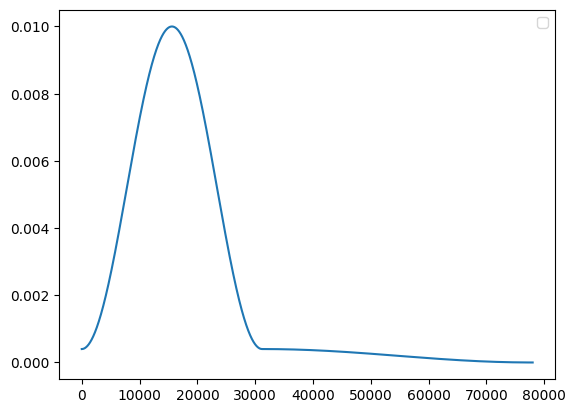

In [13]:
import utils.optimizers as optimizers
import torch
import matplotlib.pyplot as plt
%matplotlib inline

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

EPOCHS = 200
BATCHES = int(50000/128)
steps = []
lrs = []
optimizer = torch.optim.RAdam(model.parameters(), lr=0.00001, betas=[0.001,0.999],
                                                           weight_decay=0.0,
                                                           eps=1e-6) # Wrapped optimizer
optimizer = optimizers.Lookahead(optimizer=o,k=5,alpha=0.5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer.optimizer,three_phase=True,max_lr=0.01,pct_start=0.2,steps_per_epoch=BATCHES, epochs=EPOCHS)
for epoch in range(EPOCHS):
    for batch in range(BATCHES):
        scheduler.step()
        lrs.append(optimizer.param_groups[0]['lr'])
        steps.append(epoch * BATCHES + batch)

plt.figure()
plt.legend()
plt.plot(steps, lrs, label='OneCycle')
plt.show()

In [42]:
import torch.utils.benchmark as benchmark
import utils.optimizers as optimizers
import torch

EPOCHS = 200
BATCHES = int(50000/128)
steps = []
lrs = []

optimizer = torch.optim.RAdam(model.parameters(), lr=0.00001, betas=[0.001,0.999],
                                                           weight_decay=0.0,
                                                           eps=1e-6) # Wrapped optimizer
optimizer = optimizers.Lookahead(optimizer=optimizer,k=5,alpha=0.5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer.optimizer,three_phase=True,max_lr=0.01,pct_start=0.2,steps_per_epoch=BATCHES, epochs=EPOCHS)

def optstep():
    return optimizer.step()

t0 = benchmark.Timer(
    stmt='optstep()',
    setup='from __main__ import optstep',
    num_threads=4)


print(t0.timeit(100))

optstep()
setup: from __main__ import optstep
  2.30 ms
  1 measurement, 100 runs , 4 threads


/home/grios/myphyton/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


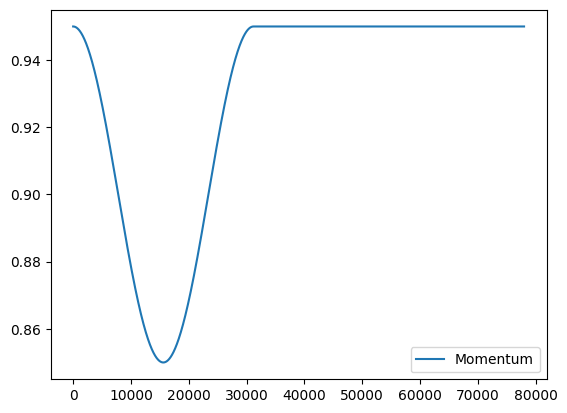

In [16]:
import utils.optimizers as optimizers
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# Function to get the momentum (beta1) from the optimizer
def get_momentum(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['betas'][0]

EPOCHS = 200
BATCHES = int(50000/128)
steps = []
momentums = []
optimizer = torch.optim.RAdam(model.parameters(), lr=0.00001, betas=[0.001,0.999],
                                                           weight_decay=0.0,
                                                           eps=1e-6) # Wrapped optimizer
optimizer = optimizers.Lookahead(optimizer=optimizer, k=5, alpha=0.5)  # Corrected 'o' to 'optimizer'
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer.optimizer, three_phase=True, max_lr=0.01, pct_start=0.2, steps_per_epoch=BATCHES, epochs=EPOCHS)

# Collecting momentum values
for epoch in range(EPOCHS):
    for batch in range(BATCHES):
        scheduler.step()
        momentums.append(get_momentum(optimizer))
        steps.append(epoch * BATCHES + batch)

# Plotting the momentum values
plt.figure()
plt.plot(steps, momentums, label='Momentum')
plt.legend()
plt.show()


In [ ]:
optimizer.param_groups[0]['lr']

4.253471299971048e-08